# Dev workflow (tactical): MACD bull/bear-cross on QQQ

Backtests a classic MACD crossover tactic on QQQ through `src2`'s TACTICAL
sleeve: buy on a bull cross (MACD line crosses above signal line), exit on
a bear cross. MACD is precomputed once, vectorized, via
`vector_calc.build_metrics_table(score_fn=vector_calc.macd_cross_score)`;
`iteration.MacdCrossStrategy` only reads that table's `score` column
(the MACD histogram) to decide BUY/EXIT -- it never recomputes MACD
live. Position sizing happens in `iteration.allocation_tactical`, not in
the strategy.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd

from src2 import vector_calc, data_ingest, iteration, evaluation

In [14]:
import matplotlib.pyplot as plt

## 1. Fetch QQQ price data

In [2]:
broker = data_ingest.DataBroker(tickers=["QQQ"], start_date="2018-01-01", end_date="2026-07-28")
world_data_dict = broker.fetch_universe_data()
price_df = world_data_dict["price"]
price_df.tail()

[*********************100%***********************]  1 of 1 completed

,QQQ
Date,
2026-07-21,708.969971
2026-07-22,705.349976
2026-07-23,691.960022
2026-07-24,684.229980
2026-07-27,682.119995


## 2. Precomputed MACD metrics table -- the strategy's actual input

This is not just a diagnostic: `df_macd_metrics` is passed straight into
`run_daily_iteration` as `df_metrics_adhoc`, and `MacdCrossStrategy` reads
its `score` column (MACD histogram = `macd_line - signal_line`) to detect
crosses. It's leak-safe by construction -- the underlying `ewm` calc is
causal, so row `t` only reflects price data through `t`.

In [3]:
df_macd_metrics = vector_calc.build_metrics_table(
    price_df,
    price_df.index.tolist(),
    score_fn=vector_calc.macd_cross_score,
    fast=12, slow=26, signal=9,
)
df_macd_metrics.tail(10)

,date,ticker,score,macd_line,signal_line
2142,2026-07-14,QQQ,-1.286678,1.078624,2.365302
2143,2026-07-15,QQQ,-1.175498,0.895929,2.071427
2144,2026-07-16,QQQ,-1.816124,-0.198728,1.617396
2145,2026-07-17,QQQ,-2.814301,-1.900480,0.913821
2146,2026-07-20,QQQ,-3.254155,-3.153872,0.100282
2147,2026-07-21,QQQ,-2.536288,-3.070078,-0.533790
2148,2026-07-22,QQQ,-2.179540,-3.258215,-1.078675
2149,2026-07-23,QQQ,-2.686364,-4.436629,-1.750266
2150,2026-07-24,QQQ,-3.340563,-5.925970,-2.585406
2151,2026-07-27,QQQ,-3.686569,-7.193618,-3.507049


## 3. Logging -- write TACTICAL rebalance/trade events to a file

In [4]:
run_logger = iteration.setup_logger(name="backtest_logger", log_file="../backtest_tactic.log")

## 4. Full backtest -- pure TACTICAL sleeve, MACD strategy, 1-hour trade delay

In [5]:
strategy = iteration.MacdCrossStrategy(ticker="QQQ", fast=12, slow=26, signal=9)

g_state, _ = iteration.run_daily_iteration(
    df_ranked=pd.DataFrame(columns=["date", "ticker", "target_weight"]),  # no CORE sleeve
    world_data_dict=world_data_dict,
    rebalance_dates=[],  # no CORE rebalances -- MACD runs entirely through the TACTICAL sleeve
    initial_capital=100_000.0,
    core_allocation_pct=0.0,
    trade_delay="1h",
    tactical_strategy=strategy,
    df_metrics_adhoc=df_macd_metrics,
    tactical_max_position_pct=1.0,
    logger=run_logger,
)

df_nav = g_state.export_nav_dataframe()
df_nav.tail()

,Core_NAV,Tactical_NAV,Total_NAV
Date,,,
2026-07-21,0.0,163765.66712,163765.66712
2026-07-22,0.0,163765.66712,163765.66712
2026-07-23,0.0,163765.66712,163765.66712
2026-07-24,0.0,163765.66712,163765.66712
2026-07-27,0.0,163765.66712,163765.66712


In [6]:
evaluation.calculate_metrics(df_nav[['Total_NAV']])

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
Total_NAV,0.059289,0.564046,0.834833,0.271521,0.218358


## 5. Plot NAV vs. buy-and-hold QQQ

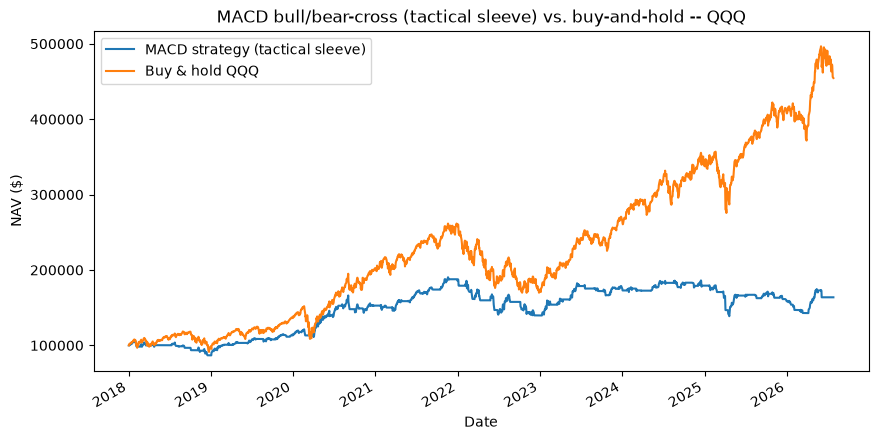

In [7]:
buy_and_hold = 100_000.0 * price_df["QQQ"] / price_df["QQQ"].iloc[0]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
df_nav["Total_NAV"].plot(ax=ax, label="MACD strategy (tactical sleeve)")
buy_and_hold.plot(ax=ax, label="Buy & hold QQQ")
ax.set_title("MACD bull/bear-cross (tactical sleeve) vs. buy-and-hold -- QQQ")
ax.set_ylabel("NAV ($)")
ax.legend()
plt.show()

---

# Hourly QQQ MACD (same strategy, hourly bars)

Same `MacdCrossStrategy`, same `run_daily_iteration` pipeline -- both are
frequency-agnostic (the loop just iterates `world_data_dict["price"].index`,
whatever its frequency is). Only the data fetch changes: `interval="1h"`
on `DataBroker`, capped by yfinance at roughly the last 730 days of
intraday history. `fast`/`slow`/`signal` are kept at the classic 12/26/9
for an apples-to-apples comparison with the daily run above -- they now
span hourly bars instead of daily ones, so retune later if the fill
frequency looks off. `trade_delay="1h"` here is one hourly bar (a short,
same-order-of-magnitude delay relative to the bar size, matching the
daily section's use of `trade_delay="1h"` relative to its daily bars).

## 1. Fetch hourly QQQ price data

In [16]:
import datetime

hourly_start = (datetime.date.today() - datetime.timedelta(days=700)).isoformat()
print(f"Fetching hourly QQQ data from {hourly_start} (yfinance's ~730-day intraday cap)")

broker_hourly = data_ingest.DataBroker(tickers=["QQQ"], start_date=hourly_start, end_date="2026-07-28", interval="1h")
world_data_hourly = broker_hourly.fetch_universe_data()
price_hourly = world_data_hourly["price"]
print(f"{len(price_hourly)} hourly bars, {price_hourly.index[0]} -> {price_hourly.index[-1]}")
price_hourly.tail()

[*********************100%***********************]  1 of 1 completed

Fetching hourly QQQ data from 2024-08-27 (yfinance's ~730-day intraday cap)
3324 hourly bars, 2024-08-27 09:30:00-04:00 -> 2026-07-27 15:30:00-04:00


,QQQ
Datetime,
2026-07-27 11:30:00-04:00,681.094971
2026-07-27 12:30:00-04:00,677.390015
2026-07-27 13:30:00-04:00,679.340027
2026-07-27 14:30:00-04:00,683.280029
2026-07-27 15:30:00-04:00,682.059998


## 2. Precomputed hourly MACD metrics table

In [17]:
df_macd_metrics_hourly = vector_calc.build_metrics_table(
    price_hourly,
    price_hourly.index.tolist(),
    score_fn=vector_calc.macd_cross_score,
    fast=12, slow=26, signal=9,
)
df_macd_metrics_hourly.tail(10)

,date,ticker,score,macd_line,signal_line
3314,2026-07-24 13:30:00-04:00,QQQ,-0.882212,-4.693050,-3.810838
3315,2026-07-24 14:30:00-04:00,QQQ,-0.972686,-5.026695,-4.054009
3316,2026-07-24 15:30:00-04:00,QQQ,-0.893580,-5.170984,-4.277404
3317,2026-07-27 09:30:00-04:00,QQQ,-1.061927,-5.604813,-4.542886
3318,2026-07-27 10:30:00-04:00,QQQ,-1.092059,-5.907960,-4.815901
3319,2026-07-27 11:30:00-04:00,QQQ,-0.883754,-5.920593,-5.036839
3320,2026-07-27 12:30:00-04:00,QQQ,-0.897386,-6.158572,-5.261186
3321,2026-07-27 13:30:00-04:00,QQQ,-0.686478,-6.119283,-5.432805
3322,2026-07-27 14:30:00-04:00,QQQ,-0.217326,-5.704463,-5.487137
3323,2026-07-27 15:30:00-04:00,QQQ,0.060287,-5.411778,-5.472065


## 3. Logging -- separate log file from the daily run

In [18]:
hourly_logger = iteration.setup_logger(name="backtest_logger", log_file="../backtest_tactic_hourly.log")

## 4. Full backtest -- pure TACTICAL sleeve, hourly bars, 1-hour trade delay

In [19]:
strategy_hourly = iteration.MacdCrossStrategy(ticker="QQQ", fast=12, slow=26, signal=9)

g_state_hourly, _ = iteration.run_daily_iteration(
    df_ranked=pd.DataFrame(columns=["date", "ticker", "target_weight"]),  # no CORE sleeve
    world_data_dict=world_data_hourly,
    rebalance_dates=[],  # no CORE rebalances -- MACD runs entirely through the TACTICAL sleeve
    initial_capital=100_000.0,
    core_allocation_pct=0.0,
    trade_delay="0h",
    tactical_strategy=strategy_hourly,
    df_metrics_adhoc=df_macd_metrics_hourly,
    tactical_max_position_pct=1.0,
    logger=hourly_logger,
)

df_nav_hourly = g_state_hourly.export_nav_dataframe()
df_nav_hourly.tail()

,Core_NAV,Tactical_NAV,Total_NAV
Date,,,
2026-07-27 11:30:00-04:00,0.0,97697.764741,97697.764741
2026-07-27 12:30:00-04:00,0.0,97697.764741,97697.764741
2026-07-27 13:30:00-04:00,0.0,97697.764741,97697.764741
2026-07-27 14:30:00-04:00,0.0,97697.764741,97697.764741
2026-07-27 15:30:00-04:00,0.0,97600.066977,97600.066977


In [20]:
evaluation.calculate_metrics(df_nav_hourly[['Total_NAV']])

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
Total_NAV,-0.012613,-0.023916,-0.036452,0.178906,-0.070501


## 5. Plot NAV vs. buy-and-hold QQQ (hourly window)

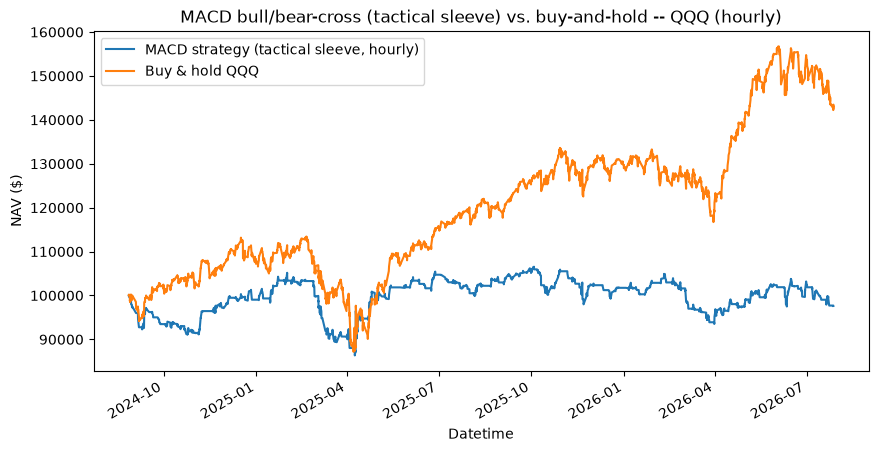

In [21]:
buy_and_hold_hourly = 100_000.0 * price_hourly["QQQ"] / price_hourly["QQQ"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 5))
df_nav_hourly["Total_NAV"].plot(ax=ax, label="MACD strategy (tactical sleeve, hourly)")
buy_and_hold_hourly.plot(ax=ax, label="Buy & hold QQQ")
ax.set_title("MACD bull/bear-cross (tactical sleeve) vs. buy-and-hold -- QQQ (hourly)")
ax.set_ylabel("NAV ($)")
ax.legend()
plt.show()

In [22]:
df_macd_metrics_hourly.to_csv('../data/macd_hourly.csv',index=False
                            )

---

# Hourly MACD entries gated by a daily MACD trend filter

Same hourly `MacdCrossStrategy` cross logic, but BUY signals additionally
require the **daily** MACD histogram to be trending up (today's daily
score higher than yesterday's) -- if the daily trend is down, no new
entries; EXIT signals still fire on an hourly bear-cross regardless,
since flattening a position should never be blocked by a trend filter.

The daily-trend check is `vector_calc.make_macd_trend_filter` -- a
standard `filter_xxx.py` (df_metrics in, boolean Series out, same
contract as `make_liquidity_filter`), so it plugs directly into
`build_target_weight_table`'s existing `filter_fn=` parameter like any
other filter (demonstrated below), not just into this tactical strategy.
It's leak-safe: the daily trend is shifted by one bar before being
broadcast onto the hourly index, so only the last fully-closed daily bar
is ever used, never the still-forming one for "today."

## 1. Build the filter, and prove it plugs into `build_target_weight_table` like any other filter

In [23]:
macd_trend_filter = vector_calc.make_macd_trend_filter(price_hourly, htf_resample="D", fast=12, slow=26, signal=9)

_df_metrics_demo, _df_ranked_demo = vector_calc.build_target_weight_table(
    price_hourly,
    price_hourly.index.tolist(),
    score_fn=vector_calc.macd_cross_score,
    filter_fn=macd_trend_filter,
    fast=12, slow=26, signal=9,
)
_df_ranked_demo[["date", "ticker", "score", "filtered_out"]].tail(10)

,date,ticker,score,filtered_out
3314,2026-07-24 13:30:00-04:00,QQQ,-0.882212,True
3315,2026-07-24 14:30:00-04:00,QQQ,-0.972686,True
3316,2026-07-24 15:30:00-04:00,QQQ,-0.893580,True
3317,2026-07-27 09:30:00-04:00,QQQ,-1.061927,True
3318,2026-07-27 10:30:00-04:00,QQQ,-1.092059,True
3319,2026-07-27 11:30:00-04:00,QQQ,-0.883754,True
3320,2026-07-27 12:30:00-04:00,QQQ,-0.897386,True
3321,2026-07-27 13:30:00-04:00,QQQ,-0.686478,True
3322,2026-07-27 14:30:00-04:00,QQQ,-0.217326,True
3323,2026-07-27 15:30:00-04:00,QQQ,0.060287,True


In [28]:
_df_metrics_demo.tail()

,date,ticker,score,macd_line,signal_line
3319,2026-07-27 11:30:00-04:00,QQQ,-0.883754,-5.920593,-5.036839
3320,2026-07-27 12:30:00-04:00,QQQ,-0.897386,-6.158572,-5.261186
3321,2026-07-27 13:30:00-04:00,QQQ,-0.686478,-6.119283,-5.432805
3322,2026-07-27 14:30:00-04:00,QQQ,-0.217326,-5.704463,-5.487137
3323,2026-07-27 15:30:00-04:00,QQQ,0.060287,-5.411778,-5.472065


## 2. Merge the filter's column onto the existing hourly metrics table (no recomputation)

In [24]:
df_macd_metrics_hourly_filtered = df_macd_metrics_hourly.copy()
df_macd_metrics_hourly_filtered["macd_trend_up"] = macd_trend_filter(df_macd_metrics_hourly_filtered).values
df_macd_metrics_hourly_filtered.tail(10)

,date,ticker,score,macd_line,signal_line,macd_trend_up
3314,2026-07-24 13:30:00-04:00,QQQ,-0.882212,-4.693050,-3.810838,False
3315,2026-07-24 14:30:00-04:00,QQQ,-0.972686,-5.026695,-4.054009,False
3316,2026-07-24 15:30:00-04:00,QQQ,-0.893580,-5.170984,-4.277404,False
3317,2026-07-27 09:30:00-04:00,QQQ,-1.061927,-5.604813,-4.542886,False
3318,2026-07-27 10:30:00-04:00,QQQ,-1.092059,-5.907960,-4.815901,False
3319,2026-07-27 11:30:00-04:00,QQQ,-0.883754,-5.920593,-5.036839,False
3320,2026-07-27 12:30:00-04:00,QQQ,-0.897386,-6.158572,-5.261186,False
3321,2026-07-27 13:30:00-04:00,QQQ,-0.686478,-6.119283,-5.432805,False
3322,2026-07-27 14:30:00-04:00,QQQ,-0.217326,-5.704463,-5.487137,False
3323,2026-07-27 15:30:00-04:00,QQQ,0.060287,-5.411778,-5.472065,False


## 3. Full backtest -- pure TACTICAL sleeve, hourly bars, daily-trend-filtered entries

In [25]:
filtered_logger = iteration.setup_logger(name="backtest_logger", log_file="../backtest_tactic_hourly_filtered.log")

strategy_filtered = iteration.MacdCrossDailyTrendFilterStrategy(ticker="QQQ", fast=12, slow=26, signal=9)

g_state_filtered, _ = iteration.run_daily_iteration(
    df_ranked=pd.DataFrame(columns=["date", "ticker", "target_weight"]),  # no CORE sleeve
    world_data_dict=world_data_hourly,
    rebalance_dates=[],  # no CORE rebalances -- MACD runs entirely through the TACTICAL sleeve
    initial_capital=100_000.0,
    core_allocation_pct=0.0,
    trade_delay="0h",
    tactical_strategy=strategy_filtered,
    df_metrics_adhoc=df_macd_metrics_hourly_filtered,
    tactical_max_position_pct=1.0,
    logger=filtered_logger,
)

df_nav_filtered = g_state_filtered.export_nav_dataframe()
df_nav_filtered.tail()

,Core_NAV,Tactical_NAV,Total_NAV
Date,,,
2026-07-27 11:30:00-04:00,0.0,93474.487,93474.487
2026-07-27 12:30:00-04:00,0.0,93474.487,93474.487
2026-07-27 13:30:00-04:00,0.0,93474.487,93474.487
2026-07-27 14:30:00-04:00,0.0,93474.487,93474.487
2026-07-27 15:30:00-04:00,0.0,93474.487,93474.487


In [26]:
evaluation.calculate_metrics(df_nav_filtered[['Total_NAV']])

,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
Total_NAV,-0.034647,-1.914052,-2.494756,0.091608,-0.37821


## 4. Plot: filtered vs. unfiltered hourly strategy vs. buy-and-hold

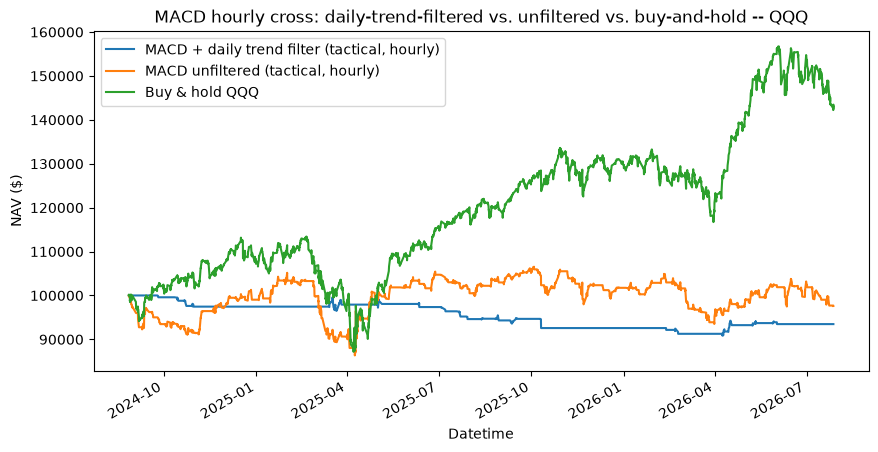

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
df_nav_filtered["Total_NAV"].plot(ax=ax, label="MACD + daily trend filter (tactical, hourly)")
df_nav_hourly["Total_NAV"].plot(ax=ax, label="MACD unfiltered (tactical, hourly)")
buy_and_hold_hourly.plot(ax=ax, label="Buy & hold QQQ")
ax.set_title("MACD hourly cross: daily-trend-filtered vs. unfiltered vs. buy-and-hold -- QQQ")
ax.set_ylabel("NAV ($)")
ax.legend()
plt.show()